/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


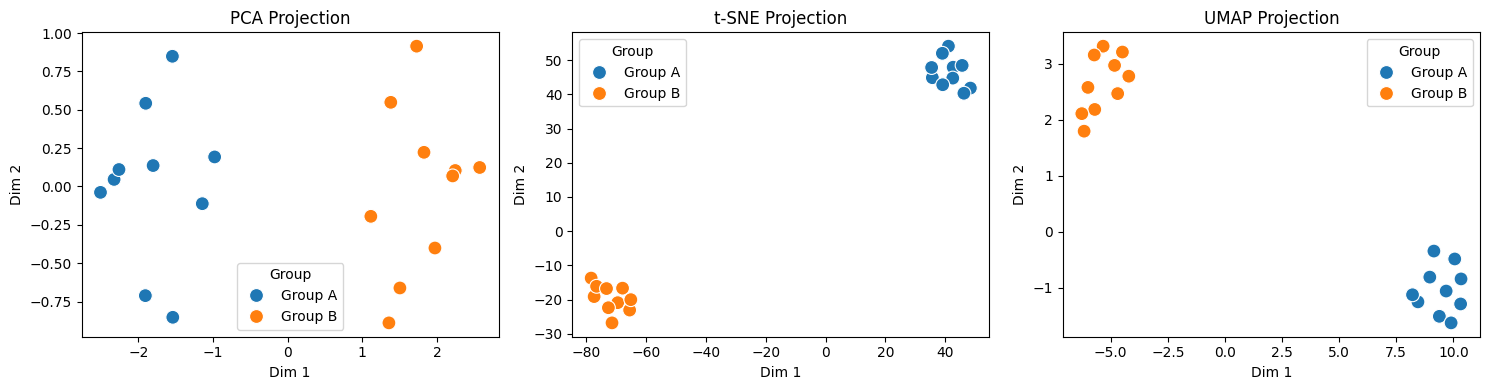

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# --- DATASET GENERATION (Do not change) ---
np.random.seed(42)
data = np.random.randn(20, 4)
data[10:, :] += 3.5 # Create 2 groups
labels = ['Group A']*10 + ['Group B']*10
df = pd.DataFrame(data, columns=['F1', 'F2', 'F3', 'F4'])

X_scaled = StandardScaler().fit_transform(df) #fiz it by standardizing the data

# PCA
pca_res = PCA(n_components=2).fit_transform(X_scaled)

tsne_res = TSNE(
    n_components=2,
    perplexity=5, #fix 2 is that we lower perplexity
    random_state=42
).fit_transform(X_scaled)

# UMAP
umap_res = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    random_state=42
).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results = [
    ('PCA', pca_res),
    ('t-SNE', tsne_res),
    ('UMAP', umap_res)
]

for ax, (title, res_data) in zip(axes, results):
    plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
    plot_df['Group'] = labels
    sns.scatterplot(
        data=plot_df,
        x='Dim 1',
        y='Dim 2',
        hue='Group', #fix 3 is that we add hue GROUP so that clusters are coloured and visually diff
        ax=ax,
        s=100
    )
    ax.set_title(f"{title} Projection")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


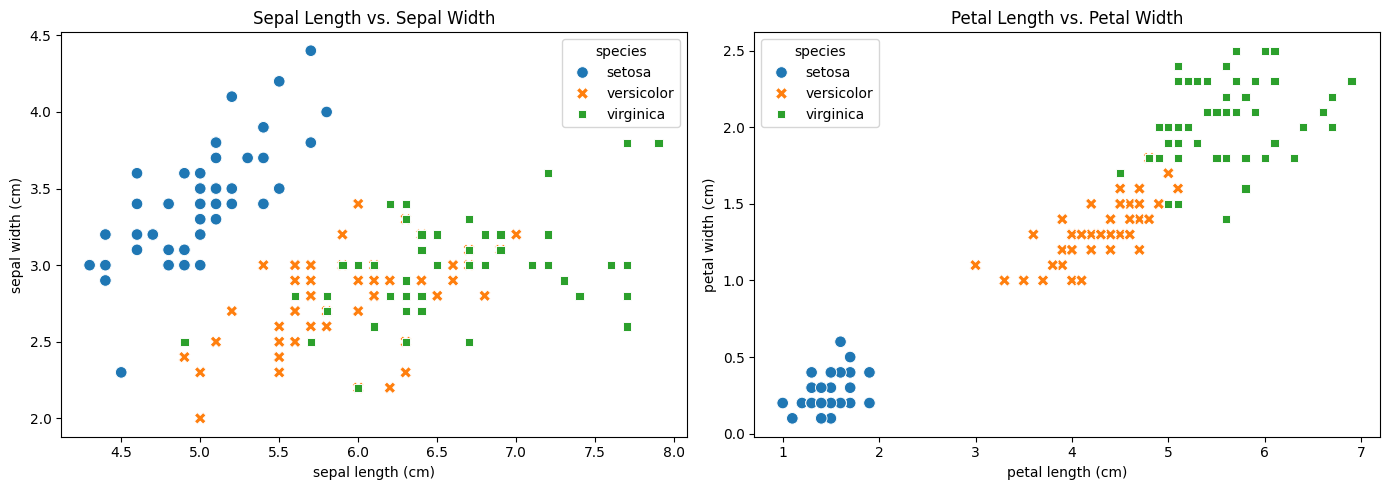

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df,x='sepal length (cm)',y='sepal width (cm)',hue='species',style='species',ax=axes[0], s=70)
axes[0].set_title("Sepal Length vs. Sepal Width")
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species', style='species', ax=axes[1], s=70)
axes[1].set_title("Petal Length vs. Petal Width")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


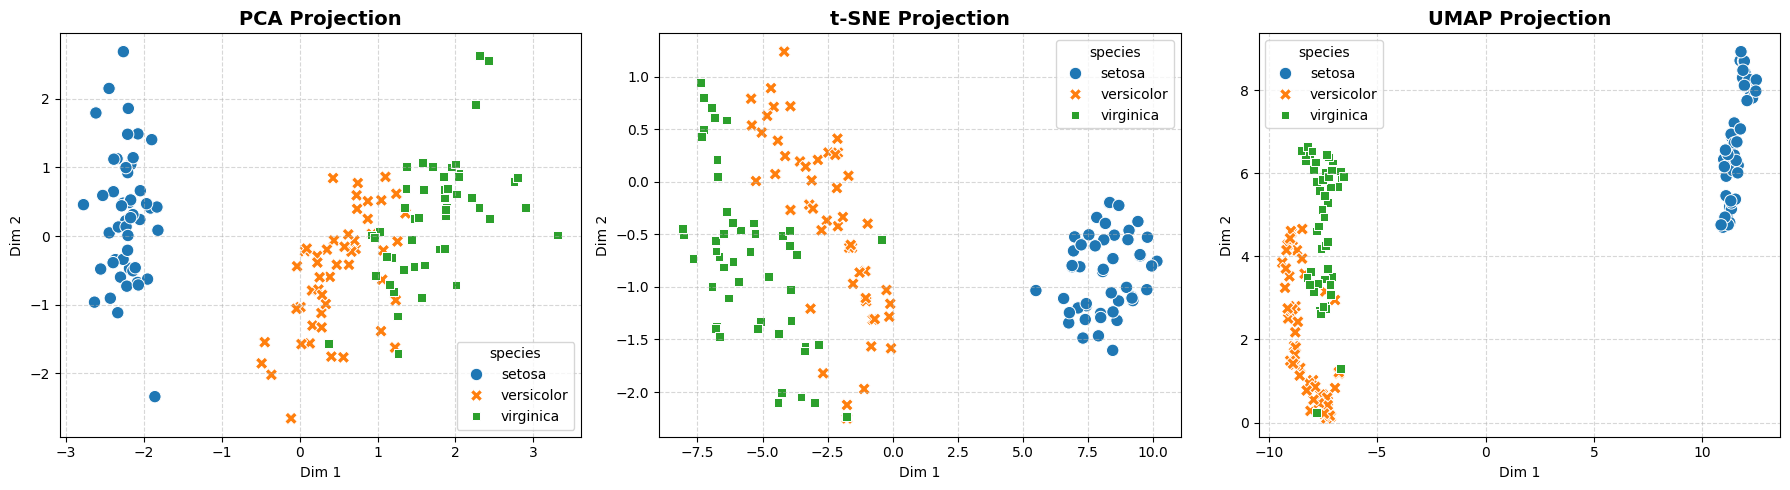

In [12]:
X = df[iris.feature_names].values
y = df['species']
X_scaled = StandardScaler().fit_transform(X)
pca_res = PCA(n_components=2).fit_transform(X_scaled)
tsne_res = TSNE(n_components=2, perplexity=50, random_state=42).fit_transform(X_scaled)
umap_res = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
algorithms = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, algorithms):
    plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
    plot_df['species'] = y
    sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2',hue='species',style='species',ax=ax,s=80)
    ax.set_title(f"{title} Projection", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()